### NetworkX

**NetworkX** is a Python library used to create, analyze, and visualize graphs.

It allows us to:

- Create nodes and edges easily
- Work with directed and undirected graphs
- Run graph algorithms (BFS, DFS, shortest path, etc.)
- Visualize graphs using matplotlib

NetworkX helps us focus on graph concepts instead of manually handling low-level details.

### Installing NetworkX

To install NetworkX, run one of the following commands in your terminal:

Using pip:

    pip install networkx

Using conda:

    conda install networkx

To visualize graphs, we also need matplotlib:

    pip install matplotlib

or

    conda install matplotlib



# Graphs

A **graph** is a mathematical structure used to represent relationships between objects.

A graph consists of:

- A set of **nodes (vertices)**
- A set of **edges** connecting some pairs of nodes

We often write this formally as:

G = (V, E)

where:
- V is the set of vertices (nodes)
- E is the set of edges

Graphs are used to model many real-world systems:
- Social networks
- Road maps
- Computer networks
- Dependencies between tasks

## Nodes

A **node** (also called a *vertex*) is a fundamental element of a graph.

- It represents an object or entity.
- Nodes can represent people, cities, computers, tasks, etc.
- A graph must contain at least one node.

In drawings, nodes are usually represented as circles.

### Graph with One Node

A graph can consist of a single vertex and no edges.

This is the simplest possible graph.

- It has **1 node**
- It has **0 edges**
- It is trivially connected

This example shows that a graph does not need edges to exist.

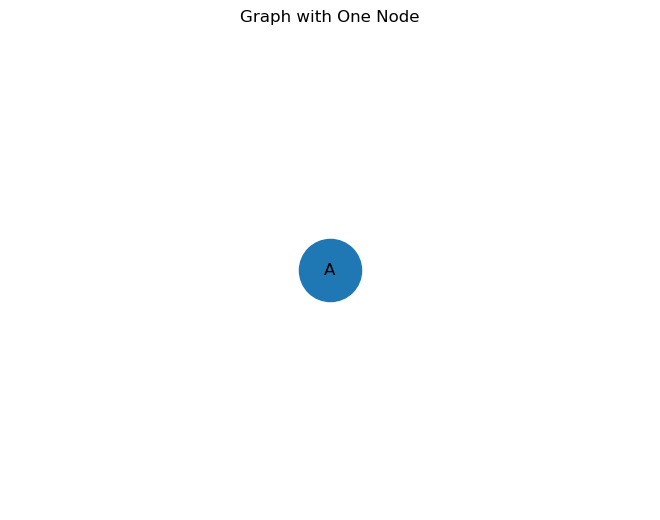

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_node("A")

nx.draw(G, with_labels=True, node_size=2000)
plt.title("Graph with One Node")
plt.show()


## Edges
An **edge** represents a connection between two nodes.

- In an **undirected graph**, the connection works both ways.
- In a **directed graph**, the edge has a direction (from one node to another).

Edges can represent:
- Friendships
- Roads
- Communication links
- Dependencies

In drawings, edges are usually represented as lines (or arrows in directed graphs).
### Two Nodes with One Edge

This graph contains:

- 2 nodes
- 1 edge connecting them

Because the edge has no direction, this is an **undirected graph**.

The two nodes are connected, so there is a path between them.

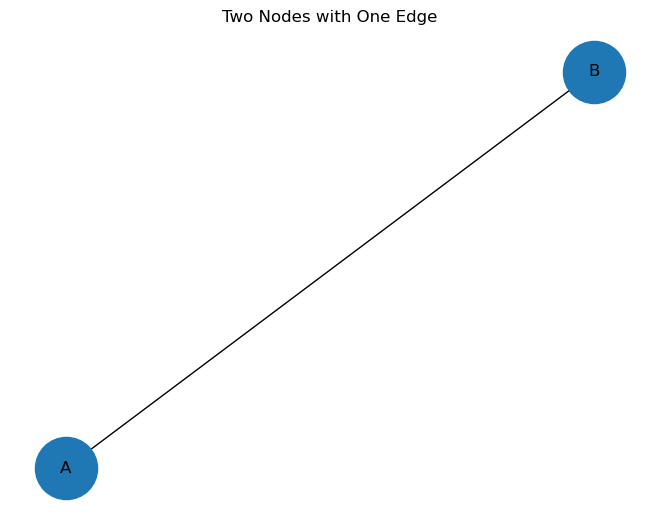

In [2]:
G = nx.Graph()
G.add_edge("A", "B")

nx.draw(G, with_labels=True, node_size=2000)
plt.title("Two Nodes with One Edge")
plt.show()

## Self Loop

A self-loop is an edge that connects a node to itself.

- The edge starts and ends at the same node.
- Self-loops are allowed in general graphs.
- However, trees cannot contain self-loops.

This example shows that graphs can contain special types of edges.

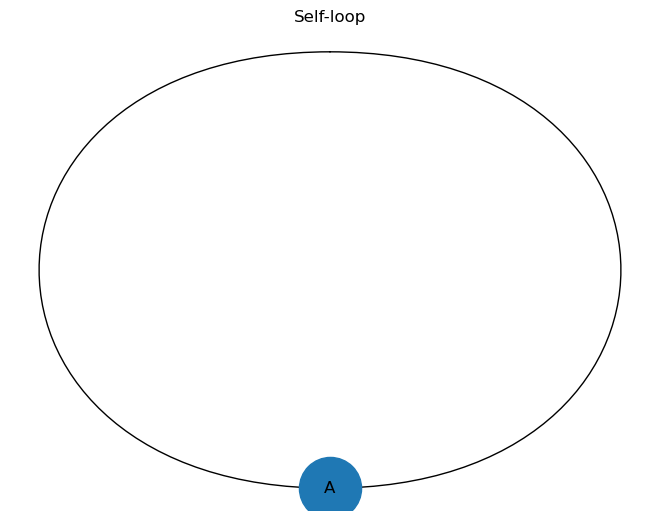

In [3]:
G = nx.Graph()
G.add_edge("A", "A")

nx.draw(G, with_labels=True, node_size=2000)
plt.title("Self-loop")
plt.show()

## Tree

A tree is a special type of graph.

Properties of a tree:

- It is **connected**
- It contains **no cycles**
- There is exactly **one simple path** between any two nodes

Trees are very important in computer science:
- File systems
- Expression trees
- Search trees

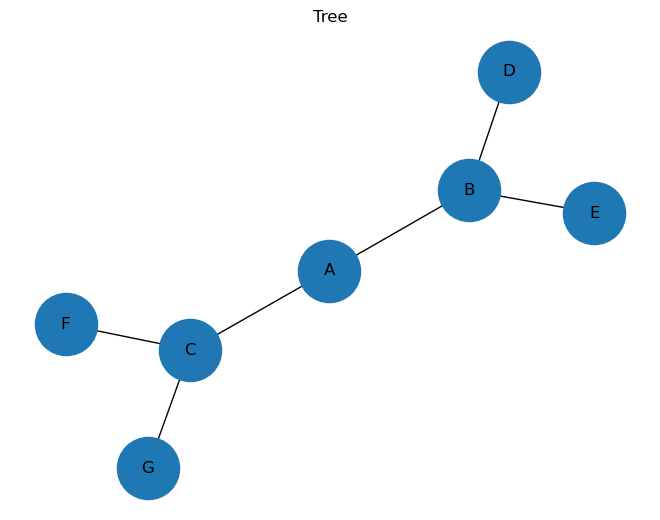

In [11]:
G = nx.Graph()
G.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("B", "E"),
    ("C", "F"),
    ("C", "G")
])

nx.draw(G, with_labels=True, node_size=2000)
plt.title("Tree")
plt.show()


## Tree with Hierarchical Layout

When visualizing a tree, we usually want:

- The root at the top
- Children below their parent
- Clear hierarchical structure

The default layout (spring layout) does not guarantee this structure.

Below we use a custom layout function to draw the tree
in a traditional hierarchical style.


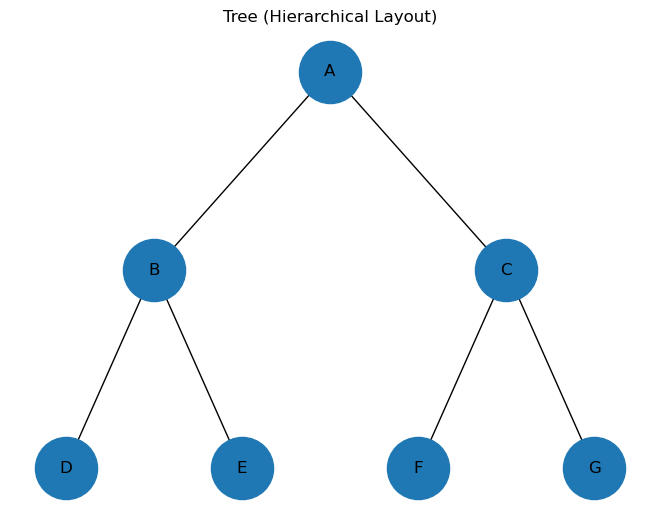

In [12]:
def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """
    Create a hierarchical layout for a tree.
    """
    pos = {}
    children = list(G.neighbors(root))

    if not isinstance(G, nx.DiGraph):
        children = [node for node in children if node != root]

    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width/2 - dx/2
        for child in children:
            nextx += dx
            pos.update(hierarchy_pos(G, child, width=dx,
                                     vert_gap=vert_gap,
                                     vert_loc=vert_loc-vert_gap,
                                     xcenter=nextx))
    pos[root] = (xcenter, vert_loc)
    return pos


# Create a tree
T = nx.DiGraph()
T.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("B", "E"),
    ("C", "F"),
    ("C", "G")
])

pos = hierarchy_pos(T, "A")

nx.draw(T, pos, with_labels=True, node_size=2000, arrows=False)
plt.title("Tree (Hierarchical Layout)")
plt.show()

## Undirected Graph

In an undirected graph:

- Edges do not have direction.
- If A is connected to B, then B is connected to A.

Undirected graphs are often used to model:
- Friendships
- Road networks (without one-way streets)
- Physical connections

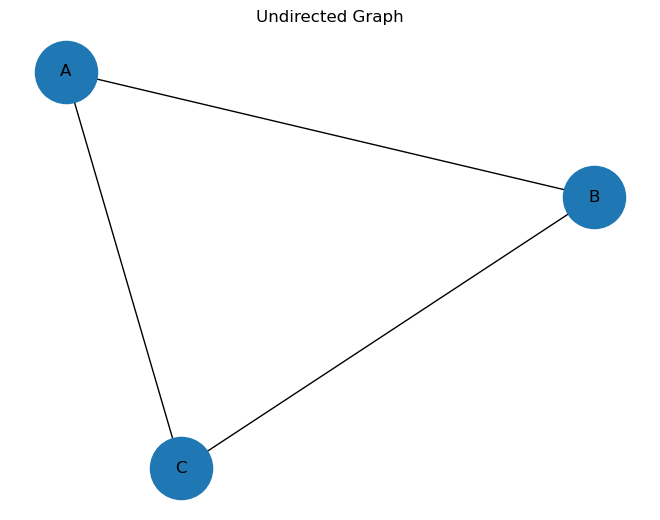

In [6]:
G = nx.Graph()
G.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
])

nx.draw(G, with_labels=True, node_size=2000)
plt.title("Undirected Graph")
plt.show()


## Directed Graph

In a directed graph (also called a digraph):

- Edges have a direction.
- If there is an edge from A to B, it does not automatically mean there is an edge from B to A.

Directed graphs are used to model:
- Social media followers
- Web links
- Task dependencies

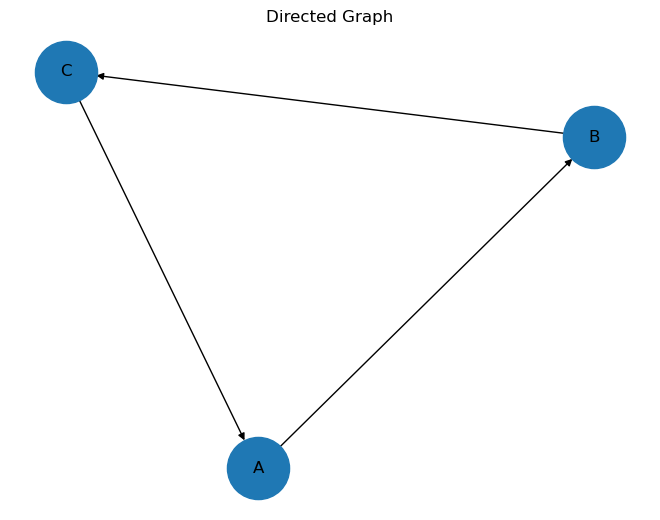

In [5]:
G = nx.DiGraph()
G.add_edges_from([
    ("A", "B"),
    ("B", "C"),
    ("C", "A"),
])

nx.draw(G, with_labels=True, node_size=2000, arrows=True)
plt.title("Directed Graph")
plt.show()

## Weighted Graph

In a **weighted graph**, each edge has a numerical value called a *weight*.

The weight can represent:

- Distance between cities
- Cost of travel
- Time required
- Strength of connection

Weighted graphs are commonly used in:
- GPS navigation systems
- Network routing
- Optimization problems

In NetworkX, we can assign a weight to an edge using the `weight` parameter.


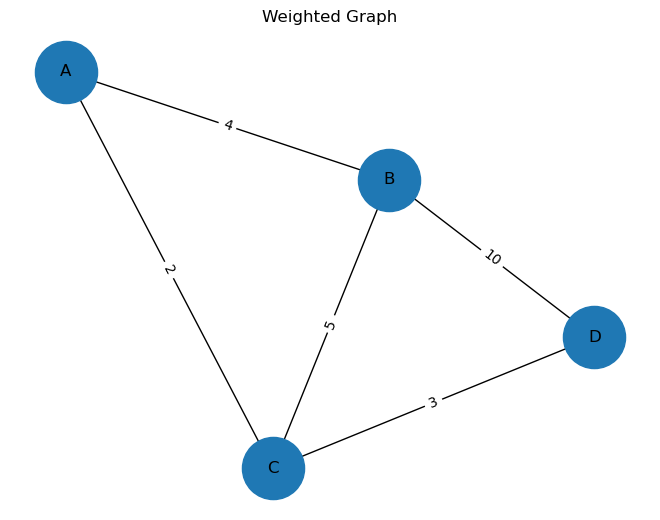

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Create weighted graph
G = nx.Graph()

G.add_edge("A", "B", weight=4)
G.add_edge("A", "C", weight=2)
G.add_edge("B", "C", weight=5)
G.add_edge("B", "D", weight=10)
G.add_edge("C", "D", weight=3)

pos = nx.spring_layout(G)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_size=2000)

# Extract edge weights
edge_labels = nx.get_edge_attributes(G, "weight")

# Draw weights on edges
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Weighted Graph")
plt.show()
